In [1]:
from Data_Functions import Get_Data, Extract_Initial_Data, Clean_and_preImpute, Impute_df
import missingno as msno
%run Models.ipynb

In [2]:
df = Get_Data('Data/train.csv')
df_test = Get_Data('Data/test.csv')

df, df_test = Extract_Initial_Data(df, df_test, version = 2)

In [3]:
df_clean, df_test_clean = Clean_and_preImpute(df, df_test)

Number of null rows before cleaning: 2087 in training data        and 996 in testing data
skewed_features:  ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'GroupSize', 'FamilySize', 'GroupFamilySize', 'CabinFamilySize', 'CabinGroupSize', 'CabinSize', 'ppId']
There are 1371 remaining null rows in training data after cleaning
and 684 remaining null rows in test data


### First let's quickly confirm that the missing data are missing completely at random.

In [4]:
main_cols = ['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 
             'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Last Name']

<Axes: >

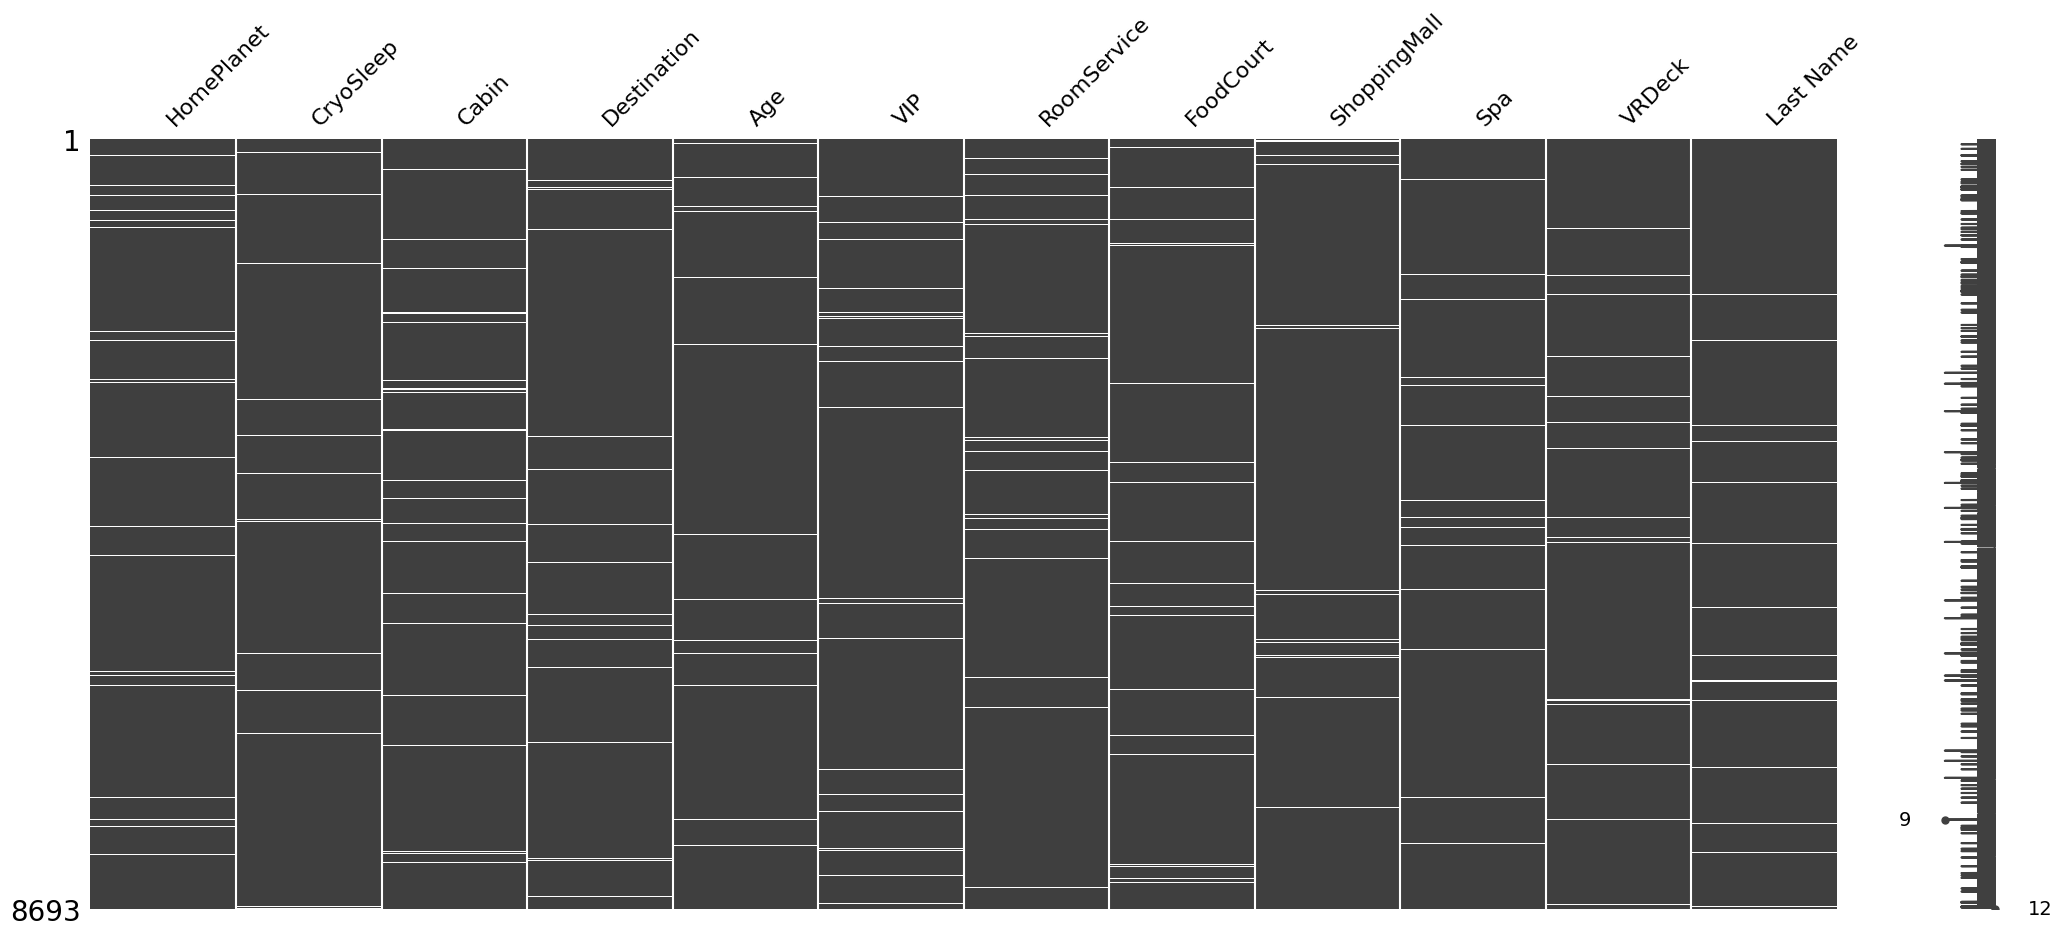

In [5]:
msno.matrix(df[main_cols])

<Axes: >

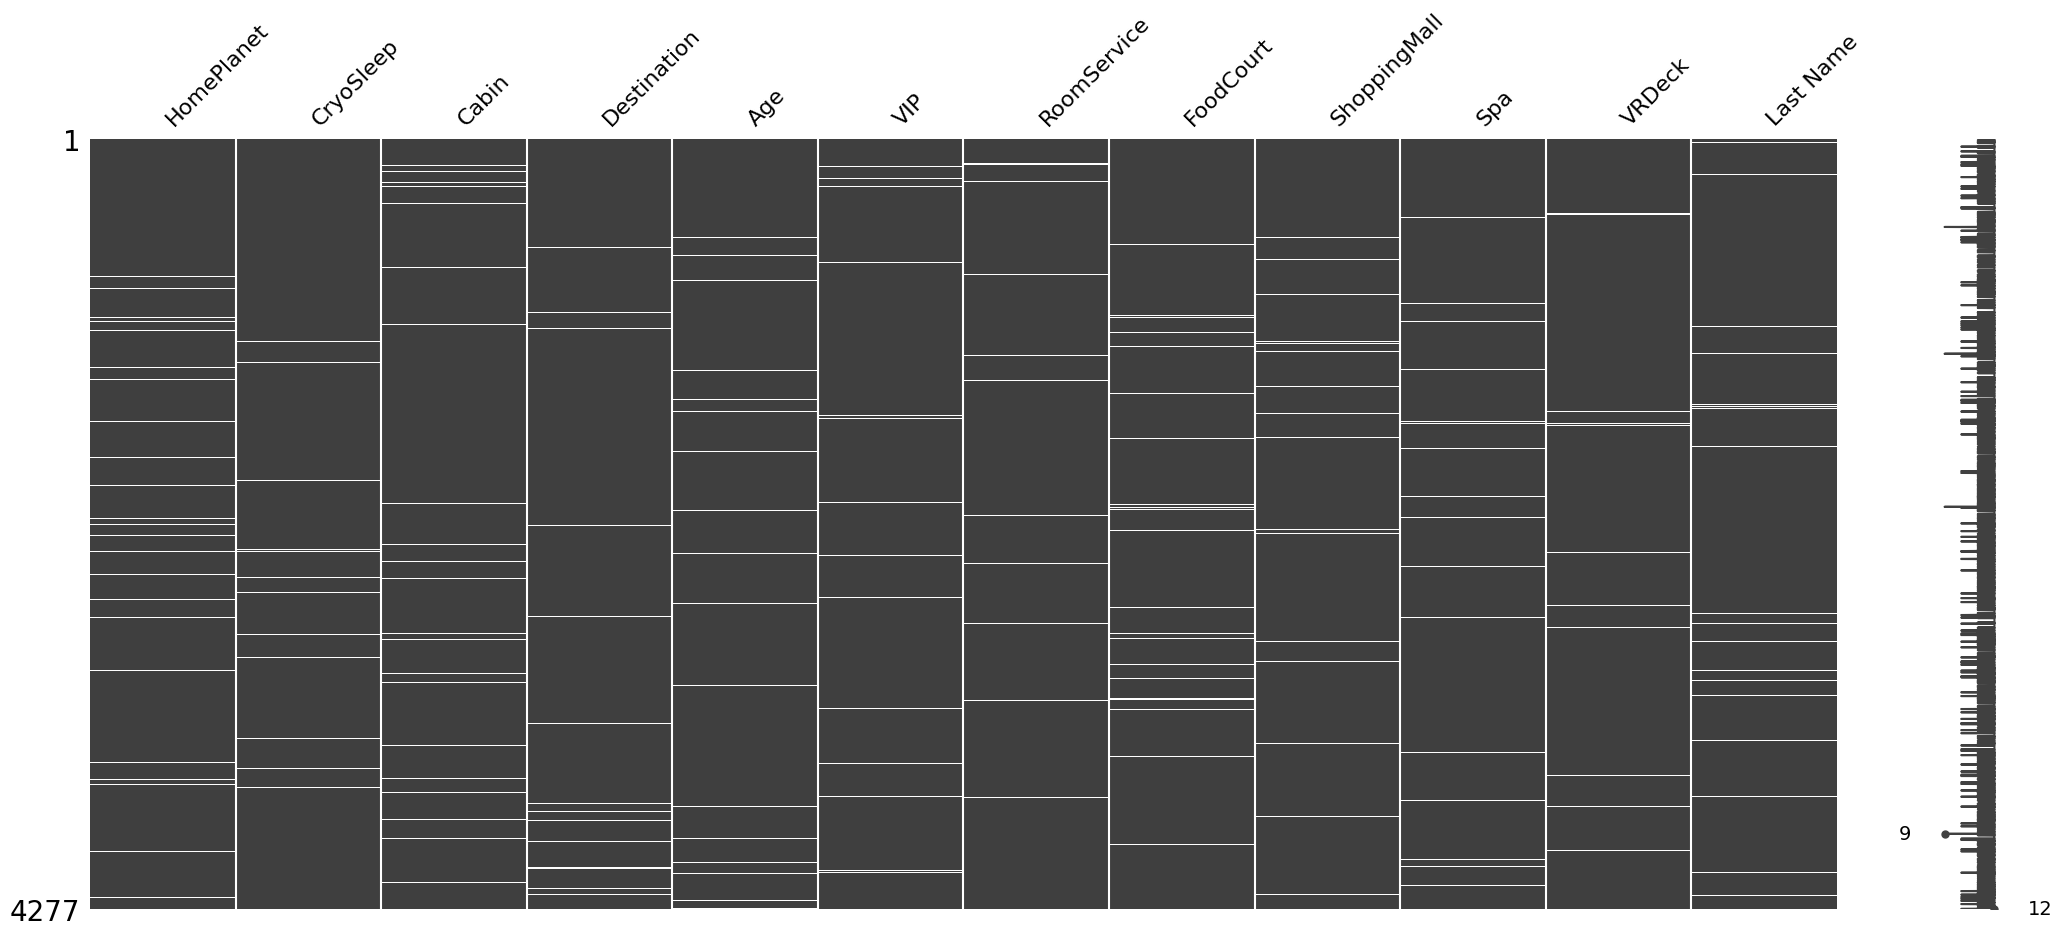

In [6]:
msno.matrix(df_test[main_cols])

<Axes: >

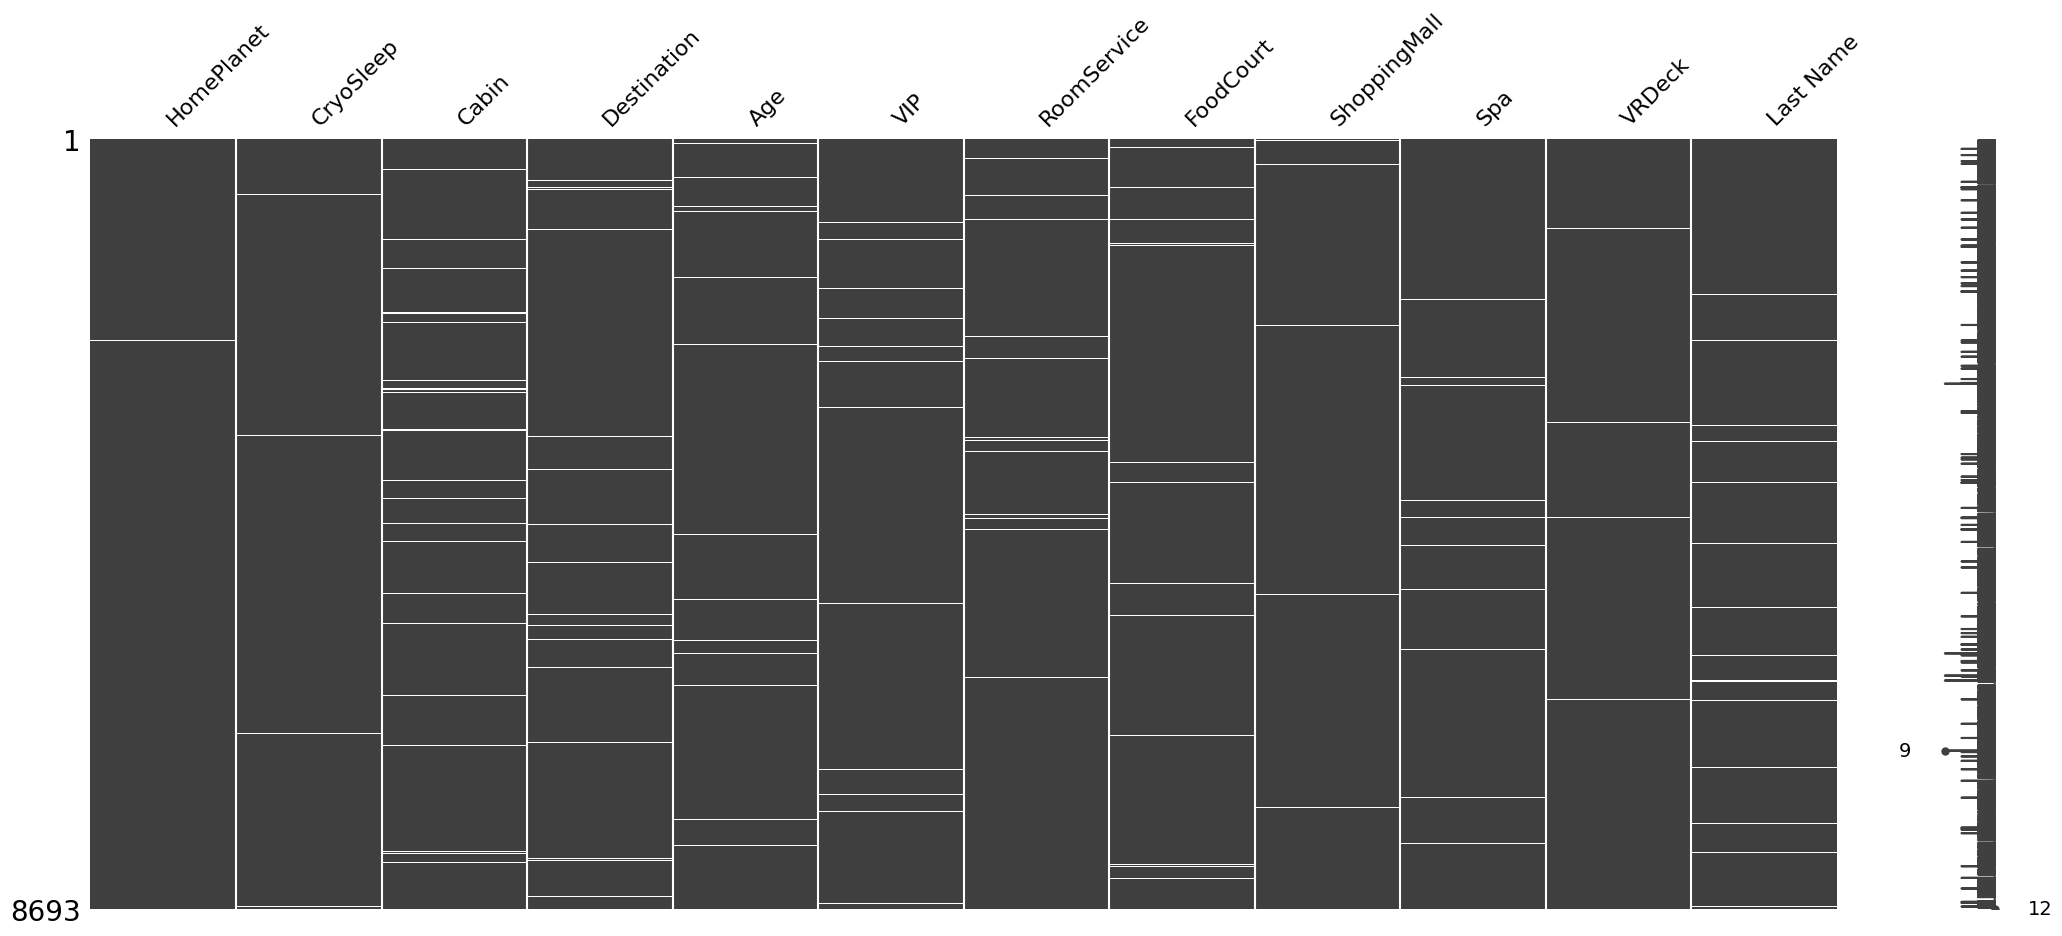

In [7]:
msno.matrix(df_clean[main_cols])

In [8]:
df[main_cols].isnull().sum()

HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Last Name       200
dtype: int64

In [9]:
df_test[main_cols].isnull().sum()

HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Last Name        94
dtype: int64

In [10]:
df_clean[main_cols].isnull().sum()

HomePlanet        5
CryoSleep        90
Cabin           199
Destination     182
Age             179
VIP              71
RoomService     107
FoodCourt       106
ShoppingMall    103
Spa             114
VRDeck          107
Last Name       200
dtype: int64

In [11]:
df_test_clean[main_cols].isnull().sum()

HomePlanet        1
CryoSleep        37
Cabin           100
Destination      92
Age              91
VIP              48
RoomService      55
FoodCourt        65
ShoppingMall     60
Spa              52
VRDeck           43
Last Name        94
dtype: int64

<font size = "4">Since the missing data is MCAR, it is possible to drop null rows without affecting the distribution of our data, though it would decrease the amount of data available for training. In this case, we also have missing data in the test set that we need to predict.<br>The next option is to replace the missing data. In the cleaning and pre-imputation process, it was possible to replace some of this missing data with their obvious values. For example, passengers in cryosleep cannot spend on luxury items, so we can set these to zero when cryosleep is true. Similarly, we can set a null cryosleep to false if any of the luxury features are greater than zero. Another obvious fill is the HomePlanet. Passengers with the same last name (presumably from the same family) have the same homeplanet.<br>Now, for the rest of the missing data, I will try three different methods:</font>
* <font size = "3">The first method, *<font color = 'blue'>impute_method = flag</font>*, would simply replace the null values with one that is outside the range of possible number values for this feature. </font>
* <font size = "3">The second method, *<font color = 'blue'>impute_method = Impute</font>*, would use imputation. Of course, there are many different imputation methods. Here I will be using the most logical course of action for each feature. It will be a combination of "domain knowledge", simple imputation, k-nearest neighbor imputation, and random value imputation that would preserve the probability distribution of the data. </font>
* <font size = "3">The third, *<font color = 'blue'>impute_method = Impute_flag</font>*, is similar to the second but will also add columns to flag imputed data.</font>

In [12]:
Destination_Features = [col for col in df_clean.columns if col.startswith('Destination_')]
HomePlanet_Features = [col for col in df_clean.columns if col.startswith('HomePlanet_')]
deck_Features = [col for col in df_clean.columns if col.startswith('deck_')]
Region_Features = [col for col in df_clean.columns if col.startswith('Region_')]
Batch_Features = [col for col in df_clean.columns if col.startswith('Batch_')]

str_cols = ['HomePlanet', 'Cabin', 'Destination', 'deck', 'side', 'Last Name', 'HomePlanetDeck', 'Age_LifeStages_lbs']
extra_cols = ['Age', 'GroupId', 'ppId', 'Cabin Number', 'GroupSize', 'FirstNameLength', 'LastNameLength', 'GroupFamilySize', 'CabinFamilySize', 
              'CabinGroupSize', 'CabinSize', 'side_P', 'Batch', 'VIP', 'Under_13', 'FamilySize', 'HomePlanetDeck_EuropaT'] + HomePlanet_Features + deck_Features + Region_Features + Batch_Features

columns_to_drop = str_cols + extra_cols

flag_features = ['CryoSleep', 'VIP', 'HomePlanet', 'Destination', 'Cabin', 'Last Name', 'RoomService', 
                 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Age_LifeStages']

In [13]:
df_flag, df_test_flag = Impute_df(df_clean, df_test_clean, impute_method = 'flag', columns_to_drop = columns_to_drop)

In [14]:
df_Impute_flag, df_test_Impute_flag = Impute_df(df_clean, df_test_clean, impute_method = 'Impute_flag', 
                                                flag_features = flag_features, 
                                                columns_to_drop = columns_to_drop)

flag_cols = df_Impute_flag.filter(regex = '^flag_').columns.to_list()

df_Impute = df_Impute_flag.drop(columns = flag_cols).copy()
df_test_Impute = df_test_Impute_flag.drop(columns = flag_cols).copy()

In [15]:
scoring = {
    'accuracy': accuracy_score, 
    'roc_auc': roc_auc_score,
    'f1_pos': lambda y_true,  y_pred: f1_score(y_true, y_pred, pos_label = 1), 
    'f1_neg': lambda y_true, y_pred: f1_score(y_true, y_pred, pos_label = 0),
    'precision_pos': lambda y_true, y_pred: precision_score(y_true, y_pred, pos_label = 1),
    'precision_neg': lambda y_true, y_pred: precision_score(y_true, y_pred, pos_label = 0),
    'recall_pos': lambda y_true, y_pred: recall_score(y_true, y_pred, pos_label = 1),
    'recall_neg': lambda y_true, y_pred: recall_score(y_true, y_pred, pos_label = 0)
}

impute_methods = {'flag': df_flag, 'Impute': df_Impute, 'Impute_flag': df_Impute_flag}
Models_list = ['Logistic Regression', 'Random Forest', 'Support Vector', 'CatBoost', 'LightGBM']

Results, Results_std = Get_Results(impute_methods, Models_list, scoring, Kfold = 10, repeats = 5)

model = Logistic Regression
impute_method = flag
fold0: scores = [0.764367816091954, 0.7643011161846779, 0.7678369195922989, 0.7607934655775963, 0.7617977528089888, 0.7670588235294118, 0.773972602739726, 0.7546296296296297]
fold1: scores = [0.771264367816092, 0.7713723997970573, 0.7688734030197445, 0.7736063708759955, 0.7825059101654847, 0.7606263982102909, 0.7557077625570776, 0.7870370370370371]
fold2: scores = [0.7988505747126436, 0.7987220953830543, 0.8035914702581369, 0.7938751472320377, 0.7902869757174393, 0.8081534772182254, 0.817351598173516, 0.7800925925925926]
fold3: scores = [0.7744533947065593, 0.774459170268667, 0.7752293577981652, 0.7736720554272517, 0.7770114942528735, 0.771889400921659, 0.7734553775743707, 0.7754629629629629]
fold4: scores = [0.7675489067894131, 0.7674485125858124, 0.7725225225225225, 0.7623529411764706, 0.7605321507760532, 0.7751196172248804, 0.7848970251716247, 0.75]
fold5: scores = [0.7721518987341772, 0.7717848478106559, 0.7833698030634574, 0.7597087

In [16]:
Style_Results_Table(Results, Models_list, list(impute_methods.keys()))

In [17]:
Style_Results_Table(Results_std, Models_list, list(impute_methods.keys()))